In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy import odr

In [2]:
# Carrega o dataset
data = load_diabetes()

# Cria o DataFrame com features + target
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [4]:
# Calulando a matriz de correlação entre feature vs alvo 

correlacao = df.corr().round(3)

correlacao_alvo = correlacao['target'].drop('target').sort_values(key=abs, ascending=False)
print('Correlação de cada feature com o target:')
print(correlacao_alvo.to_string())

Correlação de cada feature com o target:
bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s3    -0.395
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043


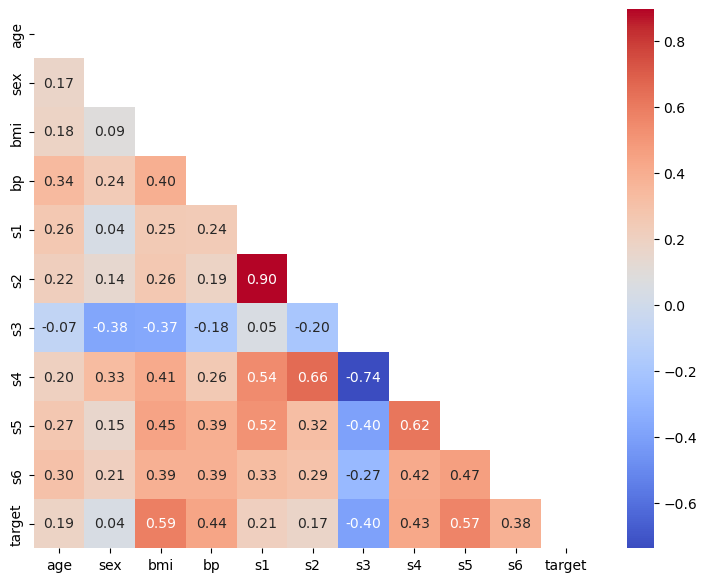

In [ ]:
# Features que são mais fortemente correlacionadas com o alvo

fig, eixo = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(correlacao, dtype=bool))
sns.heatmap(correlacao, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

# Com base no mapa de calor abaixo, podemos concluir que as features mais fortemente correlacionadas com o alvo são: bmi e s5

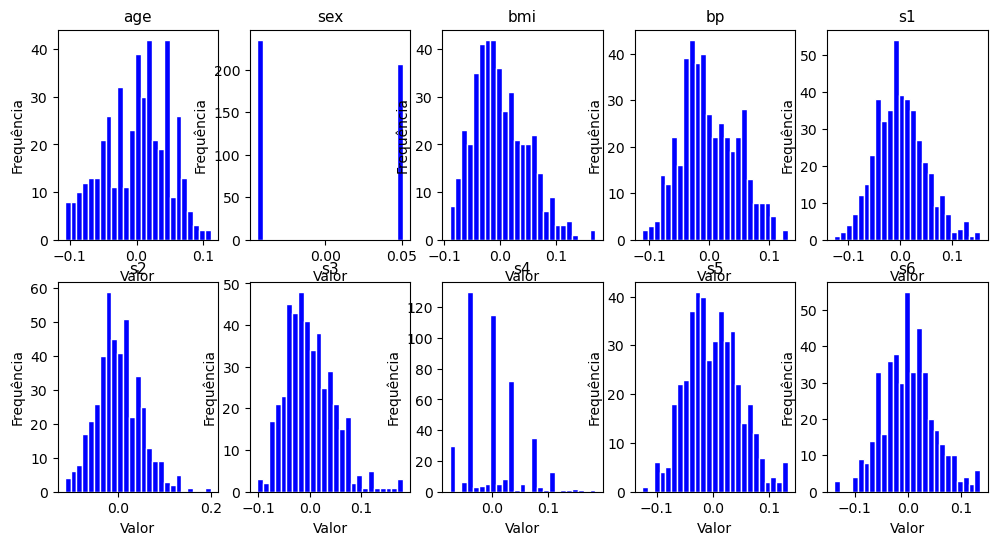

In [6]:
# Distribuição de valores por features com histogramas

features = data.feature_names
fig, eixos = plt.subplots(2, 5, figsize=(12, 6))
eixos = eixos.flatten()

for i, feat in enumerate(features):
    eixos[i].hist(df[feat], bins=25, color='blue', edgecolor='white')
    eixos[i].set_title(feat, fontsize=11)
    eixos[i].set_xlabel('Valor')
    eixos[i].set_ylabel('Frequência')
plt.show()

 Os atributos não estão completamente em escalas comparáveis. Ou seja, os atributos precisam ser normalizados, por mais que a biblioteca já entregue o dataset com algumas "configurações padronizadas" ele precisa ser normalizado pois possui algumas escalas diferentes, está sem padronização e pode gerar diversas interpretações.

In [9]:
X = df[features].values
y = df['target'].values

# Divisão 80/20 em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajuste do modelo com todas as features
model_full = LinearRegression()
model_full.fit(X_train, y_train)

r2_train_full = r2_score(y_train, model_full.predict(X_train))
r2_test_full  = r2_score(y_test,  model_full.predict(X_test))

print(f'Intercepto : {model_full.intercept_:.2f}')
print(f'R² treino  : {r2_train_full:.2f}')
print(f'R² teste   : {r2_test_full:.2f}\n')

coef_df = pd.DataFrame({'Feature': features, 'Coeficiente': model_full.coef_})\
            .sort_values('Coeficiente', key=abs, ascending=False)
print('Coeficientes de cada feature:')
print(coef_df.to_string(index=False))

Intercepto : 151.35
R² treino  : 0.53
R² teste   : 0.45

Coeficientes de cada feature:
Feature  Coeficiente
     s1  -931.488846
     s5   736.198859
    bmi   542.428759
     s2   518.062277
     bp   347.703844
     s4   275.317902
    sex  -241.964362
     s3   163.419983
     s6    48.670657
    age    37.904021


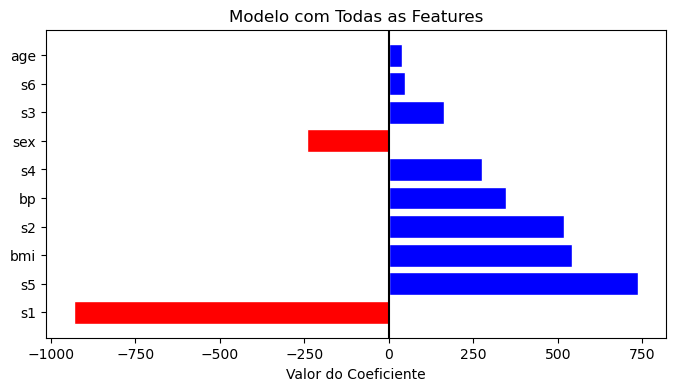

In [ ]:
# Gráfico de coeficientes

fig, eixo = plt.subplots(figsize=(8, 4))
colors = ['red' if c < 0 else 'blue' for c in coef_df['Coeficiente']]
eixo.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, edgecolor='white')
eixo.axvline(0, color='black')
eixo.set_xlabel('Valor do Coeficiente')
eixo.set_title('Modelo com Todas as Features')
plt.show()

In [12]:
# Eliminando duas features com menor correlação com o alvo

menor_correlacao = correlacao_alvo.abs().nsmallest(2).index.tolist()
print('Features eliminadas:')
print(f'  {menor_correlacao[0]}: r = {correlacao_alvo[menor_correlacao[0]]:.4f}')
print(f'  {menor_correlacao[1]}: r = {correlacao_alvo[menor_correlacao[1]]:.4f}')

Features eliminadas:
  sex: r = 0.0430
  s2: r = 0.1740


In [ ]:
# Reajustando o modelo da regressão linear e reportando novamente os coeficientes, interceptos e R² no treino e teste

features_reajustadas = [f for f in features if f not in menor_correlacao]

X_reajustado = df[features_reajustadas].values
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reajustado, y, test_size=0.2, random_state=42)

model_reajustado = LinearRegression()
model_reajustado.fit(X_train_r, y_train_r)

r2_train_red = r2_score(y_train_r, model_reajustado.predict(X_train_r))
r2_test_red  = r2_score(y_test_r,  model_reajustado.predict(X_test_r))

print('Modelo reajustado:')
print(f'Intercepto      : {model_reajustado.intercept_:.4f}')
print(f'R² treino       : {r2_train_red:.4f}')
print(f'R² teste        : {r2_test_red:.4f}\n')

coef_red_df = pd.DataFrame({'Feature': features_reajustadas, 'Coeficiente': model_reajustado.coef_})\
                .sort_values('Coeficiente', key=abs, ascending=False)
print('Coeficientes:')
print(coef_red_df.to_string(index=False))

=== Modelo REDUZIDO (8 features) ===
Features usadas : ['age', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6']
Intercepto      : 151.3480
R² treino       : 0.5080
R² teste        : 0.4389

Coeficientes:
Feature  Coeficiente
    bmi   603.207704
     s5   522.943113
     bp   301.312303
     s1  -279.114640
     s4   149.992528
     s3   -46.473316
     s6    42.355835
    age     8.774683


In [17]:
# Comparação e reflexão

comp = pd.DataFrame({
    'Modelo': ['Completo: ', 'Reajustado: '],
    'R² Treino': [r2_train_full, r2_train_red],
    'R² Teste':  [r2_test_full,  r2_test_red]
})
comp[['R² Treino', 'R² Teste']] = comp[['R² Treino', 'R² Teste']].round(4)
print(comp.to_string(index=False))

      Modelo  R² Treino  R² Teste
  Completo:      0.5279    0.4526
Reajustado:      0.5080    0.4389


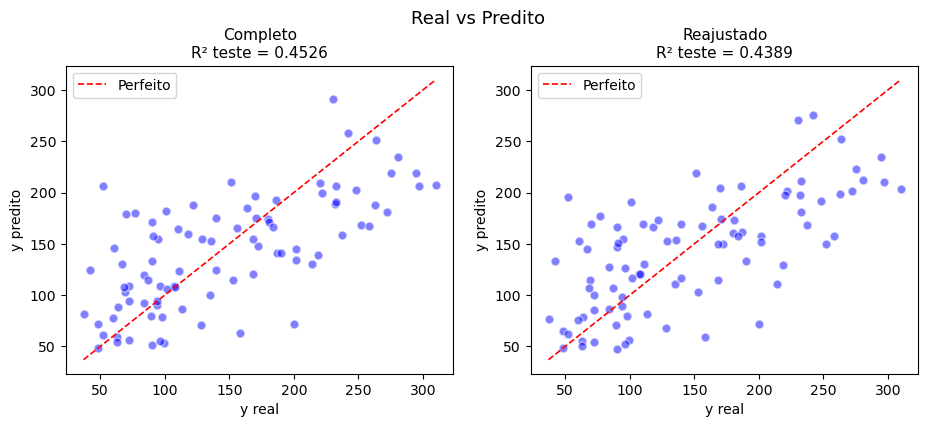

In [ ]:
# Visualização comparativa entre os modelos

fig, eixos = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for eixo, (title, model, X_tr, y_tr, X_te, y_te) in zip(eixos, [
    ('Completo', model_full, X_train, y_train, X_test, y_test),
    ('Reajustado',  model_reajustado,  X_train_r, y_train_r, X_test_r, y_test_r)
]):
    y_pred = model.predict(X_te)
    eixo.scatter(y_te, y_pred, alpha=0.5, color='blue', edgecolors='white', s=40)
    lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    eixo.plot(lims, lims, 'r--', linewidth=1.2, label='Perfeito')
    eixo.set_xlabel('y real')
    eixo.set_ylabel('y predito')
    r2 = r2_score(y_te, y_pred)
    eixo.set_title(f'{title}\nR² teste = {r2:.4f}', fontsize=11)
    eixo.legend()

plt.suptitle('Real vs Predito', fontsize=13, y=1.02)
plt.show()

# Podemos concluir que os dois modelos tem desempenho praticamente iguais. Remover correlações baixas quase não altera o R².

In [ ]:
# Feature escolhida: bmi

feature_escolhida = 'bmi'
print(f'Feature escolhida: {feature_escolhida}')
print(f'Correlação com target: r = {correlacao_alvo[feature_escolhida]:.4f}')

X1 = df[[feature_escolhida]].values
y1 = df['target'].values

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print(f'Treino: {len(X1_train)} amostras | Teste: {len(X1_test)} amostras')

Feature escolhida: "bmi"
Correlação com target: r = 0.5860
Treino: 353 amostras | Teste: 89 amostras


In [23]:
# Regressão Linear Ordinária (OLS)

ols = LinearRegression()
ols.fit(X1_train, y1_train)

m_ols = ols.coef_[0]
b_ols = ols.intercept_

y1_pred_ols = ols.predict(X1_test)

rmse_ols = np.sqrt(mean_squared_error(y1_test, y1_pred_ols))
r2_ols   = r2_score(y1_test, y1_pred_ols)

print('Mínimos Quadrados Ordinários')
print(f'  Inclinação (m) : {m_ols:.4f}')
print(f'  Intercepto (b) : {b_ols:.4f}')
print(f'  RMSE (teste)   : {rmse_ols:.4f}')
print(f'  R²   (teste)   : {r2_ols:.4f}')

Mínimos Quadrados Ordinários
  Inclinação (m) : 998.5777
  Intercepto (b) : 152.0034
  RMSE (teste)   : 63.7325
  R²   (teste)   : 0.2334


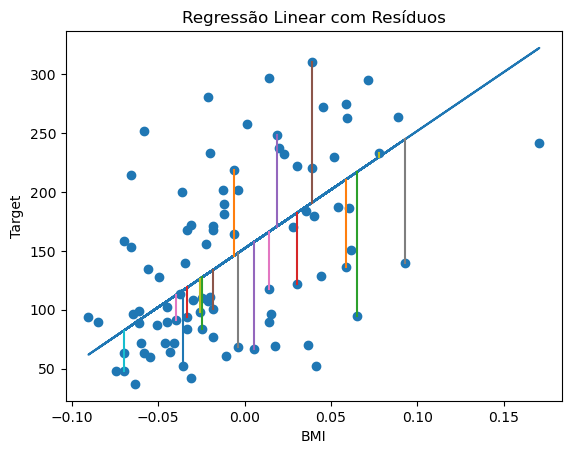

In [27]:
# Plot dos e a linha de regressão com alguns resíduos verticais

plt.scatter(X1_test, y1_test)
plt.plot(X1_test, y1_pred_ols)  

for i in range(0, len(X1_test), 5):
    plt.plot([X1_test[i], X1_test[i]],
             [y1_test[i], y1_pred_ols[i]])

plt.xlabel('BMI')
plt.ylabel('Target')
plt.title('Regressão Linear com Resíduos')

plt.show()

In [28]:
# Regressão por Distância Ortogonal (ODR/TLS)

def linear_func(beta, x):
    """Modelo linear para o ODR: y = m*x + b."""
    m, b = beta
    return m * x + b

x_tr = X1_train.ravel()
y_tr = y1_train.ravel()

# ODR
odr_model = odr.Model(linear_func)
odr_data  = odr.Data(x_tr, y_tr)
odr_fit   = odr.ODR(odr_data, odr_model, beta0=[m_ols, b_ols])
odr_output = odr_fit.run()

m_odr, b_odr = odr_output.beta

y1_pred_odr = m_odr * X1_test.ravel() + b_odr

rmse_odr = np.sqrt(mean_squared_error(y1_test, y1_pred_odr))
r2_odr   = r2_score(y1_test, y1_pred_odr)

print('ODR / TLS')
print(f'  Inclinação (m) : {m_odr:.4f}')
print(f'  Intercepto (b) : {b_odr:.4f}')
print(f'  RMSE (teste)   : {rmse_odr:.4f}')
print(f'  R²   (teste)   : {r2_odr:.4f}\n')

ODR / TLS
  Inclinação (m) : 1248.2386
  Intercepto (b) : 139.8147
  RMSE (teste)   : 68.5010
  R²   (teste)   : 0.1143



### Em que situações OLS e ODR resultam em retas significativamente diferentes?

OLS e ODR começam a dar resultados diferentes quando:

O X também tem erro
O OLS finge que o X é perfeito. Se ele tiver erro, a reta fica meio “achatada”.
Já o ODR leva isso em conta e tenta chegar mais perto da inclinação real.
X e Y variam parecido
Quando os dois têm níveis de variação parecidos, a diferença entre as retas fica mais visível.
A relação entre X e Y é fraca
Se a correlação é baixa, o OLS tende a achatar mais a reta.
O ODR normalmente mantém uma inclinação um pouco mais “realista”.

### Por que ODR é mais adequado quando X também tem erro?

O OLS só se preocupa com o erro no Y e assume que o X está perfeito (sem erro). Porém, o X também pode ter erro.

OLS → ignora erro em X → pode distorcer a reta
ODR → considera tudo → resultado mais confiável

### Como a escala afeta a solução ODR?

A distância no ODR é geométrica, ou seja, é aquela distância “reta” até a linha, mas ela depende diretamente da escala dos eixos. Isso pode virar um problema quando X e Y estão em unidades muito diferentes, porque um dos lados acaba “pesando” mais que o outro e a distância fica distorcida. Por isso, antes de aplicar o ODR, é importante padronizar os dados, colocando X e Y na mesma escala. Assim, nenhum eixo influencia mais que o outro e a ideia de “menor distância” passa a fazer sentido de forma mais justa e equilibrada.

### Qual modelo generaliza melhor?

Avaliando pelo RMSE no conjunto de teste, o OLS normalmente acaba tendo um resultado um pouco melhor, porque ele foi feito justamente pra minimizar o erro em Y (os resíduos verticais), que é exatamente o que o RMSE mede.
